In [817]:
from pathlib import Path
from typing import Literal, Callable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas.plotting import scatter_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

In [818]:
RANDOM_SEED = 42
TEST_RATIO = 0.1
TOP_N = 20
WINDOW_SIZE = 60
TOMORROW_SHIFT = -1
SHUFFLE_TRAIN_SET = False
DATA_BASE_PATH = Path("./data")

In [819]:
gold_file_path = DATA_BASE_PATH / "final_gold_data.csv"

In [820]:
gold = pd.read_csv(gold_file_path, sep=";", encoding="utf-8", parse_dates=["timestamp"])
price_cols = ["high", "low", "open", "close"]
gold.head()

,timestamp,open,high,low,close,volume,currency,unit,headlines
0,2000-08-30,273.9,273.9,273.9,273.9,0,usd,ounce,Recalls Fuel Disclosure Debate / Deutsche Tele...
1,2000-08-31,274.8,278.3,274.8,278.3,0,usd,ounce,Credit Suisse's Wheat Faces Deal / Regulators ...
2,2000-09-01,277.0,277.0,277.0,277.0,0,usd,ounce,Nordstrom's Chief Resigns / Judge Dismisses Ca...
3,2000-09-05,275.8,275.8,275.8,275.8,2,usd,ounce,Market Pace Slows After 10-Year Run / Clickman...
4,2000-09-06,274.2,274.2,274.2,274.2,0,usd,ounce,France Telecom Profit Increases / Locale-Based...


In [821]:
gold["day_variation"] = gold["open"] - gold["close"]
gold["max_diff"] = gold["high"] - gold["low"]

In [822]:
pca = PCA(n_components=1)
gold["price_pca"] = pca.fit_transform(gold[["high", "low", "open", "close"]])

In [823]:
gold["tomorrow_close"] = gold["close"].shift(TOMORROW_SHIFT)
gold = gold.dropna(subset=["tomorrow_close"])  # Remove last row with NaN

In [824]:
gold["return"] = (gold["tomorrow_close"] - gold["close"]) / gold["close"] 

In [825]:
gold["day_of_week"] = gold["timestamp"].dt.dayofweek
gold["month"] = gold["timestamp"].dt.month

In [826]:
TARGET = "return"

to_drop = [
    "currency",
    "unit",
    "timestamp",
    "headlines",
    "tomorrow_close",
]

X = gold.drop(columns=to_drop + [TARGET], axis=1)

y = gold[TARGET]

In [827]:
n_features = X.shape[1]

In [828]:
model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(WINDOW_SIZE, n_features),
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(pool_size=2))

model.add(Flatten())

model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

c:\Users\fpaul\Documents\GitHub\machine-learning-works\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [829]:
def create_sequences(X, y, window_size):

    Xs = []
    ys = []

    for i in range(len(X) - window_size):

        Xs.append(X[i:i + window_size])

        ys.append(y.iloc[i + window_size])

    return np.array(Xs), np.array(ys)

In [830]:
X_seq, y_seq = create_sequences(
    X.to_numpy(),
    y,
    WINDOW_SIZE
)

In [831]:
X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=TEST_RATIO,
    shuffle=False
)

In [832]:
scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(X_train.shape)
X_test_scaled = X_test_scaled.reshape(X_test.shape)

In [833]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    min_delta=1e-6,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.1,
    callbacks=[early_stop],
    shuffle=False
)

Epoch 1/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.8759 - mae: 0.4651 - val_loss: 0.0169 - val_mae: 0.1148
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0091 - mae: 0.0597 - val_loss: 0.0124 - val_mae: 0.0911
Epoch 3/100
 47/155 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0030 - mae: 0.0327

In [ ]:
y_pred = model.predict(X_test_scaled)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 0.04198140505338324


In [ ]:
rme_train = root_mean_squared_error(
    y_train,
    model.predict(X_train_scaled)
)

rme_test = root_mean_squared_error(
    y_test,
    model.predict(X_test_scaled)
)

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
rme_train, rme_test

(0.1718645070316907, 0.04198140505338324)

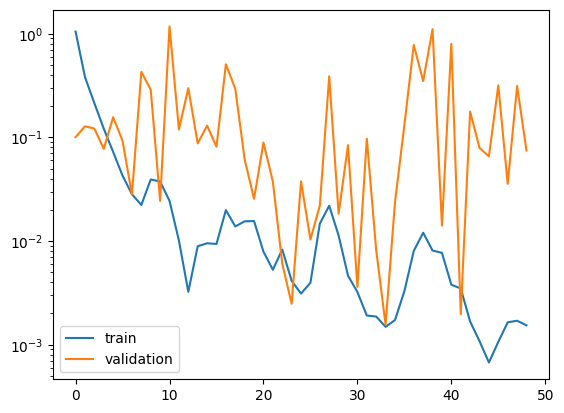

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='validation')

plt.yscale('log')

plt.legend()
plt.show()

In [ ]:
direction_acc = np.mean(
    np.sign(y_pred.flatten()) == np.sign(y_test)
)

print(direction_acc)

0.5310457516339869


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

direction_acc = np.mean(
    np.sign(y_pred.flatten()) == np.sign(y_test)
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Direction Accuracy:", direction_acc)

MAE: 0.03287155653133692
RMSE: 0.04198140505338324
R2: -19.44933672678586
Direction Accuracy: 0.5310457516339869


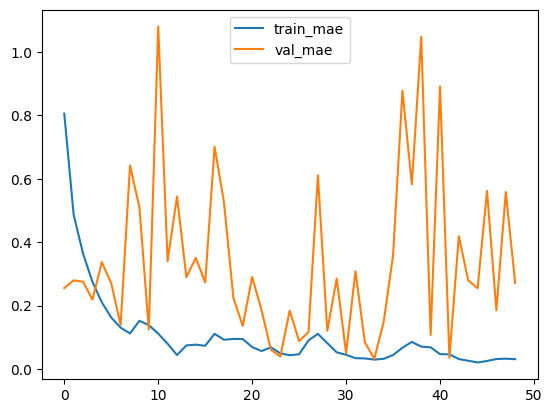

In [ ]:
plt.plot(history.history['mae'], label='train_mae')
plt.plot(history.history['val_mae'], label='val_mae')

plt.legend()
plt.show()

In [ ]:
print(np.isinf(X.to_numpy()).sum())

0
